In [1]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import davies_bouldin_score, silhouette_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# Load datasets
customers = pd.read_csv("Customers.csv")
transactions = pd.read_csv("Transactions.csv")
products = pd.read_csv("Products.csv")

In [6]:
# Merge datasets
merged_data = transactions.merge(customers, on="CustomerID").merge(products, on="ProductID")
merged_data.rename(columns={'Price_x': 'TransactionPrice', 'Price_y': 'ProductPrice'}, inplace=True)

In [7]:
# Feature Engineering
customer_features = merged_data.groupby('CustomerID').agg({
    'TotalValue': 'sum',             # Total transaction value
    'Quantity': 'sum',               # Total quantity purchased
    'TransactionPrice': 'mean',                 # Average transaction price
}).reset_index()

In [ ]:
# Add customer profile info
customer_features = customer_features.merge(customers[['CustomerID', 'Region']], on='CustomerID')

# One-hot encode categorical features
customer_features = pd.get_dummies(customer_features, columns=['Region'], drop_first=True)

# Normalize features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(customer_features.drop(columns=['CustomerID']))

In [8]:
# Clustering: K-Means
kmeans = KMeans(n_clusters=4, random_state=42)  # Choose clusters (2–10)
kmeans.fit(scaled_features)

# Add cluster labels to the data
customer_features['Cluster'] = kmeans.labels_

# Evaluate Clustering
db_index = davies_bouldin_score(scaled_features, kmeans.labels_)
silhouette_avg = silhouette_score(scaled_features, kmeans.labels_)

print(f"Davies-Bouldin Index: {db_index}")
print(f"Silhouette Score: {silhouette_avg}")

Davies-Bouldin Index: 1.1714695644070179
Silhouette Score: 0.3359017258064773


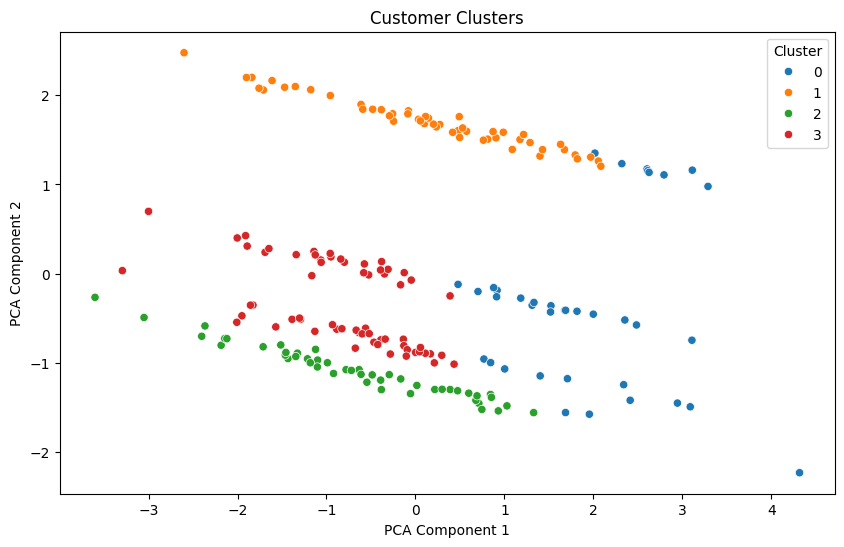

In [9]:
# Dimensionality Reduction for Visualization
pca = PCA(n_components=2)
reduced_features = pca.fit_transform(scaled_features)

# Visualize Clusters
plt.figure(figsize=(10, 6))
sns.scatterplot(x=reduced_features[:, 0], y=reduced_features[:, 1], hue=customer_features['Cluster'], palette="tab10")
plt.title("Customer Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="Cluster")
plt.show()

In [10]:
# Save results to CSV
customer_features.to_csv("Customer_Clusters.csv", index=False)